<a href="https://colab.research.google.com/github/Limeng-svg/Grounded-PPE-Safety-Copilot/blob/main/notebooks/03_yoloworld_prompt_ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This round will fix the model, images, annotations, and evaluation parameters, only changing one PPE prompt, and will automatically generate comparison results and a download package.

In [1]:
%pip -q install "ultralytics==8.4.129" "git+https://github.com/ultralytics/CLIP.git@68dce32140994dfcb645a1320c4ebdc034fc19fd"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
from pathlib import Path
from collections import Counter
from datetime import datetime, timezone
import tempfile, shutil, json

import yaml
import torch
import ultralytics
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

assert ultralytics.__version__ == "8.4.129", \
    "Please restart the Colab session and run this cell again."
assert torch.cuda.is_available(), \
    "Please set the hardware accelerator to T4 GPU."

print("GPU:", torch.cuda.get_device_name(0))

ROOT = Path(
    "/content/drive/MyDrive/Grounded-PPE-Safety-Copilot"
)
DRIVE_SOURCE = ROOT / "data/mini_eval"
REPO_ROOT = Path("/content/Grounded-PPE-Safety-Copilot")

if DRIVE_SOURCE.exists():
    SOURCE = DRIVE_SOURCE
else:
    import subprocess

    if not REPO_ROOT.exists():
        subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Limeng-svg/Grounded-PPE-Safety-Copilot.git",
                str(REPO_ROOT),
            ],
            check=True,
        )

    SOURCE = REPO_ROOT / "data/mini_eval"

assert SOURCE.exists(), f"Dataset not found: {SOURCE}"
print("Dataset source:", SOURCE)

CLASS_NAMES = [
    "person",
    "hard_hat",
    "safety_vest",
]

EXPECTED_COUNTS = Counter({
    0: 60,
    1: 53,
    2: 37,
})

images = sorted((SOURCE / "images").glob("*.jpg"))

expected_stems = {
    f"{group}_{i:02d}"
    for group in ["easy", "hard", "violation"]
    for i in range(1, 5)
}

assert len(images) == 12, "Expected 12 images but found fewer. Please check the data path and contents."
assert {p.stem for p in images} == expected_stems

# Copy data to a temporary Colab directory for faster read/write access;
# This will not modify the original images and labels in Google Drive.
LOCAL = Path(
    tempfile.mkdtemp(
        prefix="ppe_prompt_ablation_",
        dir="/content",
    )
)

for folder in ["images/val", "labels/val"]:
    (LOCAL / folder).mkdir(parents=True)

counts = Counter()

for image in images:
    label = SOURCE / "labels" / f"{image.stem}.txt"
    assert label.is_file(), f"Missing label file: {label.name}"

    for row in label.read_text(
        encoding="utf-8"
    ).splitlines():
        if row.strip():
            parts = row.split()
            assert len(parts) == 5, \
                f"Incorrect label format: {label.name}"
            counts[int(parts[0])] += 1

    shutil.copy2(
        image,
        LOCAL / "images/val" / image.name,
    )
    shutil.copy2(
        label,
        LOCAL / "labels/val" / label.name,
    )

assert counts == EXPECTED_COUNTS, \
    f"Label count mismatch: {counts}"

print("Data preparation complete: 12 images, 150 ground truth bounding boxes.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Mounted at /content/drive
GPU: Tesla T4
Data preparation complete: 12 images, 150 ground truth bounding boxes.


In [5]:
from ultralytics import YOLOWorld
# A0 is the baseline
# H1,H2 only change the safty hat propmt
# V1,V2 only change the safety vest propmt

EXPERIMENTS = [
    {
        "id": "A0",
        "hard_hat": "hard hat",
        "safety_vest": "safety vest",
    },
    {
        "id": "H1",
        "hard_hat": "safety helmet",
        "safety_vest": "safety vest",
    },
    {
        "id": "H2",
        "hard_hat": "construction helmet",
        "safety_vest": "safety vest",
    },
    {
        "id": "V1",
        "hard_hat": "hard hat",
        "safety_vest": "high visibility vest",
    },
    {
        "id": "V2",
        "hard_hat": "hard hat",
        "safety_vest": "reflective safety vest",
    },
]

# Must matching 02 evaluation parameters
VAL_ARGS = dict(
    imgsz=640,
    batch=2,
    device=0,
    workers=0,
    conf=0.001,
    iou=0.5,
    max_det=300,
    rect=False,
    augment=False,
    quantize=None,
    agnostic_nms=False,
    plots=True,
    save_json=True,
    verbose=True,
)

RUN_ID = datetime.now(
    timezone.utc
).strftime("%Y%m%dT%H%M%S_%fZ")

RUN_ROOT = (
    ROOT
    / "outputs"
    / "prompt_ablation"
    / RUN_ID
)

RUN_ROOT.mkdir(
    parents=True,
    exist_ok=False,
)

model = YOLOWorld("yolov8s-worldv2.pt")

# put the model into GPU before the first time generate the propmt features
model.to("cuda:0")

assert next(model.model.parameters()).device.type == "cuda"
print("Model is in the GPU!")

records = []

for experiment in EXPERIMENTS:
    prompts = [
        "person",
        experiment["hard_hat"],
        experiment["safety_vest"],
    ]

    # Label name of each group yaml and propmt should completely match
    yaml_path = LOCAL / f"{experiment['id']}.yaml"

    yaml_path.write_text(
        yaml.safe_dump(
            {
                "path": str(LOCAL),
                "train": None,
                "val": "images/val",
                "names": dict(enumerate(prompts)),
            },
            sort_keys=False,
        ),
        encoding="utf-8",
    )

    print("\n" + "=" * 60)
    print(
        f"Runing {experiment['id']}: {prompts}"
    )

    model.set_classes(prompts.copy())

    current_names = (
        list(model.names.values())
        if isinstance(model.names, dict)
        else list(model.names)
    )

    assert current_names == prompts, \
        f"Model and propmt not matching: {current_names}"

    metrics = model.val(
        data=str(yaml_path),
        split="val",
        project=str(RUN_ROOT),
        name=experiment["id"],
        exist_ok=False,
        **VAL_ARGS,
    )

    # Double-checked that the authenticator hasn't changed its prompts.
    metric_names = (
        list(metrics.names.values())
        if isinstance(metrics.names, dict)
        else list(metrics.names)
    )
    assert metric_names == prompts

    # Verified read 150 frames for real
    assert [
        int(x) for x in metrics.nt_per_class
    ] == [60, 53, 37]

    # The array line number of AP is able not to amount to label number, Therefore, explicit mapping is established.
    ap_rows = {
        int(class_id): row
        for row, class_id
        in enumerate(metrics.box.ap_class_index)
    }
    assert set(ap_rows) == {0, 1, 2}

    record = {
        "experiment": experiment["id"],
        "person_prompt": prompts[0],
        "hard_hat_prompt": prompts[1],
        "safety_vest_prompt": prompts[2],
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        "run_dir": str(metrics.save_dir),
    }

    for class_id, canonical_name in enumerate(
        CLASS_NAMES
    ):
        row = ap_rows[class_id]

        record[
            f"{canonical_name}_AP50"
        ] = float(metrics.box.ap50[row])

        record[
            f"{canonical_name}_AP50_95"
        ] = float(metrics.box.ap[row])

    records.append(record)

    print(
        f"{experiment['id']} completed："
        f"mAP50={record['mAP50']:.2%}，"
        f"mAP50-95={record['mAP50_95']:.2%}"
    )

    progress = {
        "dataset_role":
            "development_only_not_final_test",
        "model": "yolov8s-worldv2.pt",
        "validation_settings": VAL_ARGS,
        "experiments_completed": records,
    }

    (
        RUN_ROOT
        / "prompt_ablation_progress.json"
    ).write_text(
        json.dumps(
            progress,
            ensure_ascii=False,
            indent=2,
            allow_nan=False,
        ),
        encoding="utf-8",
    )

    del metrics
    torch.cuda.empty_cache()

print("\nAll 5 sets of experiments were completed.")
print("Result directory: ", RUN_ROOT)

Model is in the GPU!

Runing A0: ['person', 'hard hat', 'safety vest']


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 243MiB/s]


Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-worldv2 summary: 236 layers, 164,026,601 parameters, 151,277,313 gradients, 31.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3131.1±2026.6 MB/s, size: 1729.8 KB)
val: Scanning /content/ppe_prompt_ablation_a9kfldix/labels/val... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 186.2it/s 0.1s
val: New cache created: /content/ppe_prompt_ablation_a9kfldix/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.3it/s 2.6s
                   all         12        150      0.789      0.541      0.703      0.409
                person         12         60      0.891      0.983       0.99      0.654
              hard hat         10         53      0.969      0.586      0.857      0.465
           safety vest          9         37      0.508     0.0541      0.263      0.109
Speed: 0.5ms preprocess, 19.7ms

,experiment,hard_hat_prompt,safety_vest_prompt,person_AP50_95,hard_hat_AP50_95,safety_vest_AP50_95,mAP50_95
0,A0,hard hat,safety vest,65.35%,46.53%,10.87%,40.92%
1,H1,safety helmet,safety vest,65.43%,48.40%,10.46%,41.43%
2,H2,construction helmet,safety vest,65.28%,47.48%,10.22%,40.99%
3,V1,hard hat,high visibility vest,65.18%,46.56%,8.64%,40.13%
4,V2,hard hat,reflective safety vest,64.57%,46.41%,13.22%,41.40%


Best hard-hat prompt: safety helmet
Hard-hat AP50-95 change from baseline: +1.86%
Best safety-vest prompt: reflective safety vest
Safety-vest AP50-95 change from baseline: +2.35%


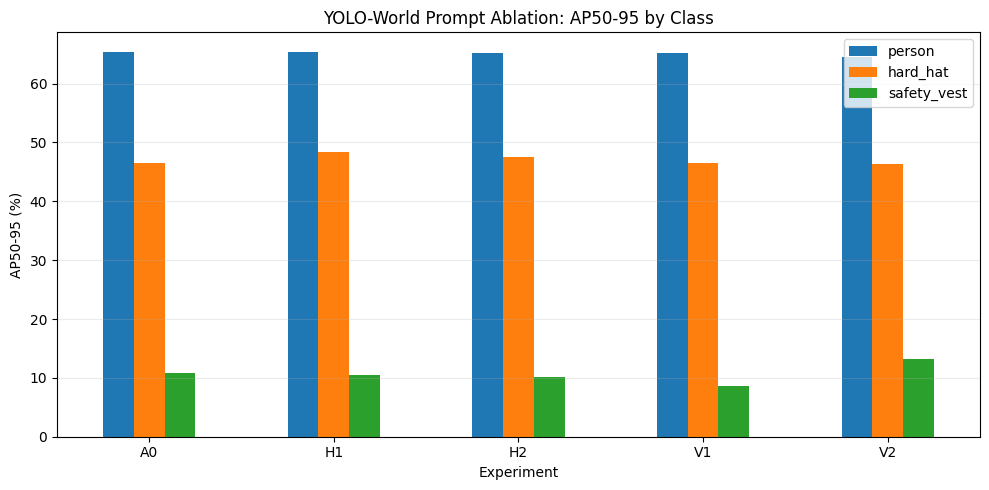

Results saved to: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/prompt_ablation/20260906T074425_822948Z


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files

results_df = pd.DataFrame(records)

results_csv = (
    RUN_ROOT
    / "prompt_ablation_results.csv"
)

results_json = (
    RUN_ROOT
    / "prompt_ablation_results.json"
)

results_df.to_csv(
    results_csv,
    index=False,
)

payload = {
    "dataset_role":
        "development_only_not_final_test",
    "image_count": 12,
    "gt_counts": {
        CLASS_NAMES[class_id]: number
        for class_id, number in sorted(
            counts.items()
        )
    },
    "model": "yolov8s-worldv2.pt",
    "ultralytics_version":
        ultralytics.__version__,
    "torch_version":
        str(torch.__version__),
    "validation_settings":
        VAL_ARGS,
    "experiments":
        records,
}

results_json.write_text(
    json.dumps(
        payload,
        ensure_ascii=False,
        indent=2,
        allow_nan=False,
    ),
    encoding="utf-8",
)

show_columns = [
    "experiment",
    "hard_hat_prompt",
    "safety_vest_prompt",
    "person_AP50_95",
    "hard_hat_AP50_95",
    "safety_vest_AP50_95",
    "mAP50_95",
]

display(
    results_df[show_columns].style.format({
        column: "{:.2%}"
        for column in show_columns
        if column.endswith("95")
    })
)

baseline = results_df.loc[
    results_df["experiment"] == "A0"
].iloc[0]

best_hat = (
    results_df[
        results_df["experiment"].isin(
            ["A0", "H1", "H2"]
        )
    ]
    .sort_values(
        [
            "hard_hat_AP50_95",
            "hard_hat_AP50",
        ],
        ascending=False,
    )
    .iloc[0]
)

best_vest = (
    results_df[
        results_df["experiment"].isin(
            ["A0", "V1", "V2"]
        )
    ]
    .sort_values(
        [
            "safety_vest_AP50_95",
            "safety_vest_AP50",
        ],
        ascending=False,
    )
    .iloc[0]
)

print(
    "Best hard-hat prompt:",
    best_hat["hard_hat_prompt"],
)

print(
    "Hard-hat AP50-95 change from baseline:",
    f"{best_hat['hard_hat_AP50_95'] - baseline['hard_hat_AP50_95']:+.2%}",
)

print(
    "Best safety-vest prompt:",
    best_vest["safety_vest_prompt"],
)

print(
    "Safety-vest AP50-95 change from baseline:",
    f"{best_vest['safety_vest_AP50_95'] - baseline['safety_vest_AP50_95']:+.2%}",
)

# Generate a class-level AP50-95 comparison chart

plot_columns = [
    "person_AP50_95",
    "hard_hat_AP50_95",
    "safety_vest_AP50_95",
]

ax = (
    results_df
    .set_index("experiment")[plot_columns]
    .mul(100)
    .plot(
        kind="bar",
        figsize=(10, 5),
        rot=0,
    )
)

ax.set_title(
    "YOLO-World Prompt Ablation: AP50-95 by Class"
)
ax.set_xlabel("Experiment")
ax.set_ylabel("AP50-95 (%)")

ax.legend([
    "person",
    "hard_hat",
    "safety_vest",
])

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    RUN_ROOT
    / "prompt_ablation_AP50_95.png",
    dpi=160,
)

plt.show()

# Create the ZIP file outside RUN_ROOT to prevent
# the archive from including itself.

archive_base = (
    Path("/content")
    / f"prompt_ablation_results_{RUN_ID}"
)

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=RUN_ROOT,
)

print("Results saved to:", RUN_ROOT)

files.download(archive_path)

In [8]:
from datetime import datetime, timezone
from pathlib import Path
import json
import shutil
import yaml
import numpy as np
import torch

from google.colab import files
from ultralytics import YOLOWorld

# Experiment configuration
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Grounded-PPE-Safety-Copilot"
)

C1_PROMPTS = [
    "person",
    "safety helmet",
    "reflective safety vest",
]

VAL_ARGS_C1 = {
    "imgsz": 640,
    "batch": 2,
    "device": 0,
    "workers": 0,
    "conf": 0.001,
    "iou": 0.5,
    "max_det": 300,
    "rect": False,
    "augment": False,
    "agnostic_nms": False,
    "plots": True,
    "save_json": True,
    "verbose": True,
}

assert torch.cuda.is_available(), (
    "GPU is unavailable. Select a GPU runtime in Colab."
)

# Find the existing three-class YOLO dataset YAML

def normalize_names(names):
    if isinstance(names, dict):
        ordered_keys = sorted(
            names,
            key=lambda key: int(key),
        )
        names = [names[key] for key in ordered_keys]

    return [
        str(name)
        .lower()
        .replace("_", " ")
        .replace("-", " ")
        .strip()
        for name in names
    ]


def check_dataset_yaml(candidate):
    try:
        data = yaml.safe_load(
            candidate.read_text(encoding="utf-8")
        )

        if not isinstance(data, dict):
            return None

        if "val" not in data or "names" not in data:
            return None

        names = normalize_names(data["names"])

        if len(names) != 3:
            return None

        has_person = any(
            "person" in name
            for name in names
        )

        has_helmet = any(
            "hat" in name or "helmet" in name
            for name in names
        )

        has_vest = any(
            "vest" in name
            for name in names
        )

        if has_person and has_helmet and has_vest:
            return data

    except Exception:
        pass

    return None


candidate_paths = []

# First inspect path variables created by earlier notebook cells
for variable_name in [
    "DATA_YAML",
    "BASE_YAML",
    "LOCAL_YAML",
    "DATA_CONFIG",
    "LOCAL",
    "DATA_ROOT",
    "DATASET_ROOT",
    "ROOT",
]:
    value = globals().get(variable_name)

    if value is None:
        continue

    try:
        path_value = Path(value)
    except TypeError:
        continue

    if (
        path_value.is_file()
        and path_value.suffix.lower()
        in {".yaml", ".yml"}
    ):
        candidate_paths.append(path_value)

    elif path_value.is_dir():
        for pattern in ("*.yaml", "*.yml"):
            candidate_paths.extend(
                path_value.rglob(pattern)
            )

# Search the project folder for both extensions
for pattern in ("*.yaml", "*.yml"):
    candidate_paths.extend(
        PROJECT_ROOT.rglob(pattern)
    )

# Search common Colab temporary-data locations
content_root = Path("/content")

for pattern in [
    "*.yaml",
    "*.yml",
    "*/*.yaml",
    "*/*.yml",
    "*/*/*.yaml",
    "*/*/*.yml",
]:
    candidate_paths.extend(
        content_root.glob(pattern)
    )

# Remove duplicates and generated output configurations
candidate_paths = sorted(
    {
        path.resolve()
        for path in candidate_paths
        if path.exists()
        and "site-packages" not in path.parts
        and ".git" not in path.parts
        and "outputs" not in path.parts
    }
)

source_yaml = None
source_data = None

for candidate in candidate_paths:
    checked_data = check_dataset_yaml(candidate)

    if checked_data is not None:
        source_yaml = candidate
        source_data = checked_data
        break

if source_yaml is None:
    print("YAML files examined:")

    for candidate in candidate_paths[:50]:
        print(" -", candidate)

    raise FileNotFoundError(
        "No three-class PPE dataset YAML was found. "
        "Please send the printed YAML list."
    )

print("Selected dataset YAML:", source_yaml)
print(
    "Original class names:",
    source_data["names"],
)
print("Validation images:", source_data["val"])

print("Source dataset YAML:", source_yaml)

# Create a C1 dataset configuration with the new prompts
run_id = datetime.now(timezone.utc).strftime(
    "%Y%m%dT%H%M%S_%fZ"
)

run_root = (
    PROJECT_ROOT
    / "outputs"
    / "prompt_combined"
    / run_id
)

run_root.mkdir(
    parents=True,
    exist_ok=False,
)

c1_data = dict(source_data)

source_root = Path(
    c1_data.get("path", source_yaml.parent)
)

if not source_root.is_absolute():
    source_root = (
        source_yaml.parent / source_root
    ).resolve()

c1_data["path"] = str(source_root)
c1_data["names"] = C1_PROMPTS
c1_data["nc"] = len(C1_PROMPTS)

c1_yaml = run_root / "C1_data.yaml"

c1_yaml.write_text(
    yaml.safe_dump(
        c1_data,
        sort_keys=False,
        allow_unicode=True,
    ),
    encoding="utf-8",
)

# Move the model before setting classes.
# This prevents the CPU/CUDA device mismatch.
model = YOLOWorld("yolov8s-worldv2.pt")
model.to("cuda:0")
model.set_classes(C1_PROMPTS.copy())

metrics = model.val(
    data=str(c1_yaml),
    project=str(run_root),
    name="C1",
    exist_ok=False,
    **VAL_ARGS_C1,
)

# Extract per-class metrics
all_ap = np.asarray(metrics.box.all_ap)
class_indices = np.asarray(
    metrics.box.ap_class_index
).astype(int)

canonical_names = {
    0: "person",
    1: "hard_hat",
    2: "safety_vest",
}

per_class = {}

for row_index, class_id in enumerate(class_indices):
    per_class[canonical_names[class_id]] = {
        "AP50": float(all_ap[row_index, 0]),
        "AP50_95": float(
            all_ap[row_index].mean()
        ),
    }

assert set(per_class) == {
    "person",
    "hard_hat",
    "safety_vest",
}

result = {
    "experiment": "C1",
    "dataset_role": "development_only_not_final_test",
    "prompts": C1_PROMPTS,
    "model": "yolov8s-worldv2.pt",
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
    "per_class": per_class,
    "validation_settings": VAL_ARGS_C1,
    "run_dir": str(metrics.save_dir),
}

# Previous strict AP50-95 reference results
reference = {
    "A0": {
        "person": 0.6535392793,
        "hard_hat": 0.4653248464,
        "safety_vest": 0.1086765889,
    },
    "H1_best_hat": {
        "hard_hat": 0.4839704201,
    },
    "V2_best_vest": {
        "safety_vest": 0.1321735564,
    },
}

result["comparison_percentage_points"] = {
    "person_vs_A0": 100 * (
        per_class["person"]["AP50_95"]
        - reference["A0"]["person"]
    ),
    "hard_hat_vs_A0": 100 * (
        per_class["hard_hat"]["AP50_95"]
        - reference["A0"]["hard_hat"]
    ),
    "hard_hat_vs_H1": 100 * (
        per_class["hard_hat"]["AP50_95"]
        - reference["H1_best_hat"]["hard_hat"]
    ),
    "safety_vest_vs_A0": 100 * (
        per_class["safety_vest"]["AP50_95"]
        - reference["A0"]["safety_vest"]
    ),
    "safety_vest_vs_V2": 100 * (
        per_class["safety_vest"]["AP50_95"]
        - reference["V2_best_vest"]["safety_vest"]
    ),
}

result_path = run_root / "C1_comparison.json"

result_path.write_text(
    json.dumps(
        result,
        ensure_ascii=False,
        indent=2,
        allow_nan=False,
    ),
    encoding="utf-8",
)

print(json.dumps(result, indent=2))

# Create the archive outside run_root
archive_base = (
    Path("/content")
    / f"C1_combined_results_{run_id}"
)

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=run_root,
)

print("Results saved to:", run_root)
files.download(archive_path)

Selected dataset YAML: /content/ppe_prompt_ablation_a9kfldix/A0.yaml
Original class names: {0: 'person', 1: 'hard hat', 2: 'safety vest'}
Validation images: images/val
Source dataset YAML: /content/ppe_prompt_ablation_a9kfldix/A0.yaml
Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-worldv2 summary: 236 layers, 164,026,601 parameters, 151,277,313 gradients, 31.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3776.4±231.3 MB/s, size: 1369.2 KB)
val: Scanning /content/ppe_prompt_ablation_a9kfldix/labels/val.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 3.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 4.7it/s 1.3s
                   all         12        150      0.827      0.644       0.73      0.419
                person         12         60      0.902      0.983       0.99      0.649
         safety helmet         10         53     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>